# Logistic Regression — Bake-Off Pipeline

**Dataset:** Heart Disease (`cleaned_merged_heart_dataset.csv`)

This notebook follows the standard **Bake-Off Pipeline** methodology:

1. Dataset Loading & Preview
2. Preprocessing Pipeline
3. Hyperparameter Tuning Log
4. Final Model Selection Leaderboard
5. Best Model Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 1. Dataset Loading & Preview

Load the dataset and inspect the first few rows (mirroring the dataset preview at the top of each Excel sheet).


In [3]:
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Filter the dataset for `thal = 2` and `thal = 3`

Restrict the analysis to the two clinically meaningful `thal` categories.


In [4]:
filtered_df = df[df['thal'].isin([2, 3])].copy()
print(f"Filtered shape: {filtered_df.shape}")
display(filtered_df.head())


Filtered shape: (1662, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


## 2. Preprocessing Pipeline

A structured preprocessing pipeline, organised the same way as the Titanic sheet in the bake-off template.

### 1. Handling Missing Values (Imputation)
- **Numeric columns:** Use the **median** to avoid the influence of outliers.
- **Categorical columns:** Use the **mode** (most frequent value).

### 2. Feature Engineering / Selection
- Drop redundant text columns (`sex_text`, `thal_text`) since `sex` and `thal` are already numerical.
- Separate features (`X`) from target (`y`).

### 3. Categorical Encoding
- `sex` and `thal` are already label-encoded as numeric → no further encoding required.

### 4. Feature Scaling (Normalization)
- Apply **StandardScaler** to put all features on a comparable scale (important for L1/L2 regularization to act fairly across features).
- Formula (per feature): `z = (x - mean) / std`


In [5]:
# 1. Handling Missing Values
num_cols = filtered_df.select_dtypes(include=np.number).columns
cat_cols = filtered_df.select_dtypes(exclude=np.number).columns

for c in num_cols:
    if filtered_df[c].isna().any():
        filtered_df[c] = filtered_df[c].fillna(filtered_df[c].median())
for c in cat_cols:
    if filtered_df[c].isna().any():
        filtered_df[c] = filtered_df[c].fillna(filtered_df[c].mode().iloc[0])

# 2. Feature Engineering / Selection
X = filtered_df.drop('target', axis=1)
y = filtered_df['target']

for col in ['sex_text', 'thal_text']:
    if col in X.columns:
        X = X.drop(col, axis=1)

# 3. Categorical Encoding — already numeric, nothing to do.

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Preprocessing complete.")
print(f"Feature matrix X: {X_scaled.shape}")
print(f"Target vector y: {y.shape}")


Preprocessing complete.
Feature matrix X: (1662, 13)
Target vector y: (1662,)


### Train / Test Split

A 70/30 stratified split keeps class balance consistent across folds.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")


Shape of X_train: (1163, 13)
Shape of X_test:  (499, 13)


## 3. Hyperparameter Tuning Log — Logistic Regression

Each row below is a single experiment in the bake-off. Columns mirror the **Hyperparameter Tuning Log** in the Excel template:

| Exp ID | Regularization (C) | Penalty Type | Solver | Validation Accuracy | F1-Score | Status | Insights |

- **Status** flags how each trial compares to the baseline (`LR_01`): *Baseline*, *Better*, *Worse*, or *Overfitting?*.
- **Insights** is a short qualitative note explaining the result.


In [7]:
experiments = [
    {'Exp ID': 'LR_01', 'C': 0.01, 'Penalty Type': 'l2', 'Solver': 'lbfgs'},
    {'Exp ID': 'LR_02', 'C': 1.0,  'Penalty Type': 'l2', 'Solver': 'lbfgs'},
    {'Exp ID': 'LR_03', 'C': 10.0, 'Penalty Type': 'l1', 'Solver': 'liblinear'},
    {'Exp ID': 'LR_04', 'C': 1.0,  'Penalty Type': 'l1', 'Solver': 'liblinear'},
    {'Exp ID': 'LR_05', 'C': 0.1,  'Penalty Type': 'l2', 'Solver': 'saga'},
]

results = []
trained_models = {}

for exp in experiments:
    model = LogisticRegression(
        C=exp['C'],
        penalty=exp['Penalty Type'],
        solver=exp['Solver'],
        max_iter=2000,
        random_state=42,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append({
        'Exp ID': exp['Exp ID'],
        'Regularization (C)': exp['C'],
        'Penalty Type': exp['Penalty Type'],
        'Solver': exp['Solver'],
        'Validation Accuracy': round(acc, 4),
        'F1-Score': round(f1, 4),
    })
    trained_models[exp['Exp ID']] = model

results_df = pd.DataFrame(results)

# --- Status column (Baseline / Better / Worse / Overfitting?) ---
baseline_acc = results_df.iloc[0]['Validation Accuracy']

def status_for(row, baseline):
    acc = row['Validation Accuracy']
    if row['Exp ID'] == 'LR_01':
        return 'Baseline'
    if row['Regularization (C)'] >= 10 and acc < baseline + 0.01:
        return 'Overfitting?'
    if acc > baseline:
        return 'Better'
    if acc < baseline:
        return 'Worse'
    return 'Same'

results_df['Status'] = results_df.apply(lambda r: status_for(r, baseline_acc), axis=1)

# --- Insights column ---
insights_map = {
    'LR_01': 'Strong regularization (C=0.01) — likely underfitting; reference point.',
    'LR_02': 'Default C=1.0 with L2 — balanced bias / variance tradeoff.',
    'LR_03': 'High C with L1 — sparse coefficients; risk of overfitting.',
    'LR_04': 'L1 penalty at default C — useful for implicit feature selection.',
    'LR_05': 'Saga solver supports both penalties; moderate regularization.',
}
results_df['Insights'] = results_df['Exp ID'].map(insights_map)

display(results_df)


,Exp ID,Regularization (C),Penalty Type,Solver,Validation Accuracy,F1-Score,Status,Insights
0,LR_01,0.01,l2,lbfgs,0.8136,0.8235,Baseline,Strong regularization (C=0.01) — likely underf...
1,LR_02,1.00,l2,lbfgs,0.8076,0.8168,Worse,Default C=1.0 with L2 — balanced bias / varian...
2,LR_03,10.00,l1,liblinear,0.8076,0.8168,Overfitting?,High C with L1 — sparse coefficients; risk of ...
3,LR_04,1.00,l1,liblinear,0.8076,0.8168,Worse,L1 penalty at default C — useful for implicit ...
4,LR_05,0.10,l2,saga,0.8076,0.8168,Worse,Saga solver supports both penalties; moderate ...


## 4. Final Model Selection Leaderboard

Sorted by **Validation Accuracy** (descending), with the same column layout as the Excel leaderboard:
`Rank | Model | Best Hyperparameters | Accuracy | F1-Score | Note`.


In [8]:
ranked = results_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

def note_for(rank, total):
    if rank == 0:
        return 'Top Performer'
    if rank == 1:
        return 'Strong Runner-up'
    if rank == total - 1:
        return 'Weak Baseline'
    return 'Acceptable'

leaderboard = pd.DataFrame({
    'Rank': range(1, len(ranked) + 1),
    'Model': ['Logistic Regression'] * len(ranked),
    'Best Hyperparameters': ranked.apply(
        lambda r: f"C={r['Regularization (C)']}, {r['Penalty Type']}, {r['Solver']}", axis=1
    ),
    'Accuracy': ranked['Validation Accuracy'],
    'F1-Score': ranked['F1-Score'],
    'Note': [note_for(i, len(ranked)) for i in range(len(ranked))],
})

display(leaderboard)

best_exp_id = ranked.iloc[0]['Exp ID']
best_model  = trained_models[best_exp_id]
print(f"\nBest experiment: {best_exp_id}")
print(f"Hyperparameters: {leaderboard.iloc[0]['Best Hyperparameters']}")
print(f"Accuracy:        {leaderboard.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score:        {leaderboard.iloc[0]['F1-Score']:.4f}")


,Rank,Model,Best Hyperparameters,Accuracy,F1-Score,Note
0,1,Logistic Regression,"C=0.01, l2, lbfgs",0.8136,0.8235,Top Performer
1,2,Logistic Regression,"C=1.0, l2, lbfgs",0.8076,0.8168,Strong Runner-up
2,3,Logistic Regression,"C=10.0, l1, liblinear",0.8076,0.8168,Acceptable
3,4,Logistic Regression,"C=1.0, l1, liblinear",0.8076,0.8168,Acceptable
4,5,Logistic Regression,"C=0.1, l2, saga",0.8076,0.8168,Weak Baseline



Best experiment: LR_01
Hyperparameters: C=0.01, l2, lbfgs
Accuracy:        0.8136
F1-Score:        0.8235


## 5. Best Model Analysis

Detailed evaluation of the top-ranked experiment from the leaderboard.


In [9]:
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_exp_id}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))


Best Model: LR_01
Accuracy:   0.8136

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       243
           1       0.80      0.85      0.82       256

    accuracy                           0.81       499
   macro avg       0.81      0.81      0.81       499
weighted avg       0.81      0.81      0.81       499



### Confusion Matrix

- **True Negatives (Top-Left):** Correctly predicted negative cases.
- **False Positives (Top-Right):** Incorrectly predicted positive cases (Type I error).
- **False Negatives (Bottom-Left):** Incorrectly predicted negative cases (Type II error).
- **True Positives (Bottom-Right):** Correctly predicted positive cases.


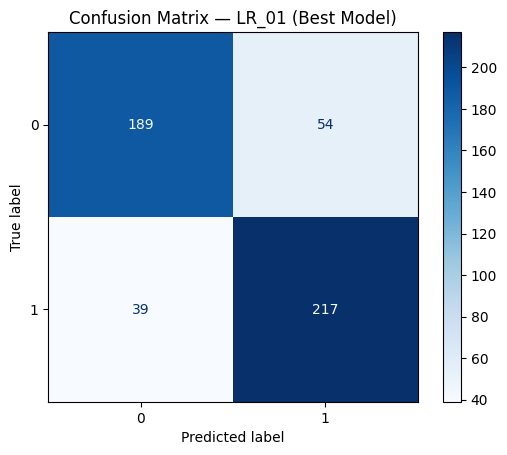

In [10]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix — {best_exp_id} (Best Model)')
plt.show()


### Feature Importance (Coefficients)

For logistic regression, coefficients represent the change in log-odds of the outcome for a one-unit increase in the feature. Larger **absolute** values imply greater importance.


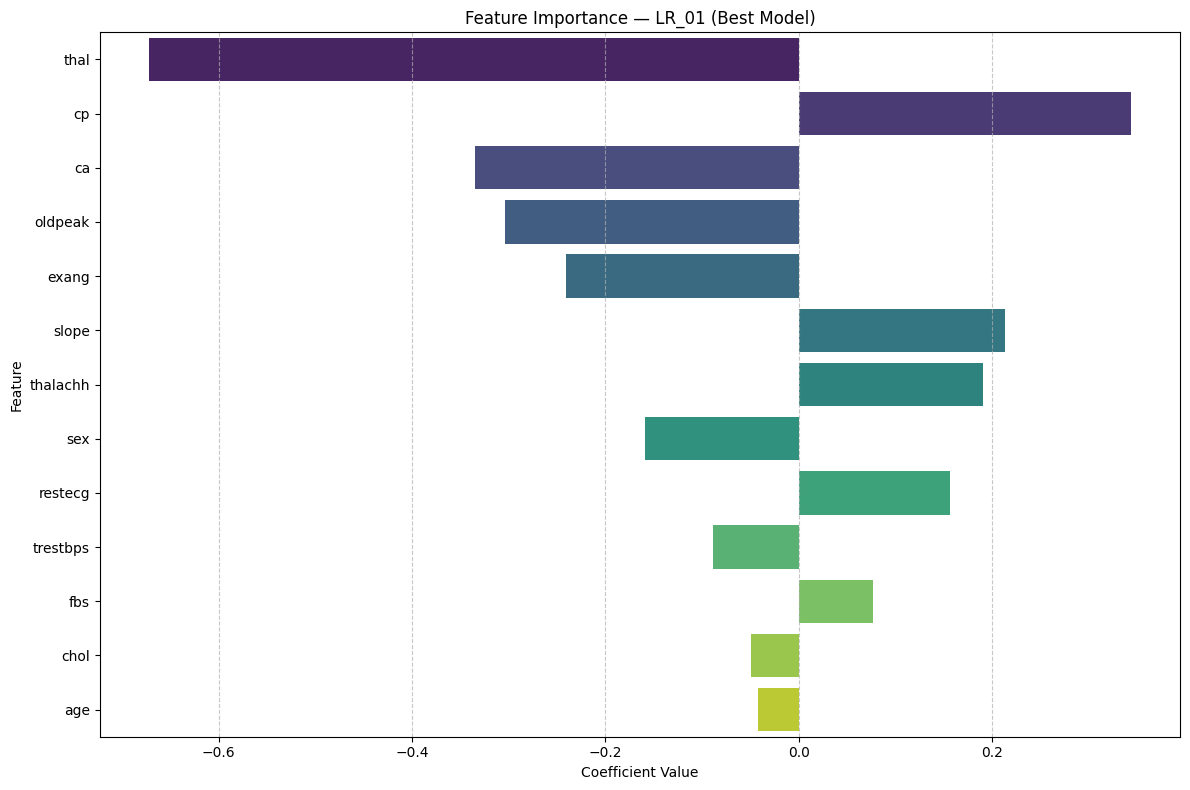

In [11]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0],
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='coefficient', y='feature', data=feature_importance,
    palette='viridis', hue='feature', legend=False,
)
plt.title(f'Feature Importance — {best_exp_id} (Best Model)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Conclusion

The Logistic Regression bake-off ran **5 experiments** (`LR_01`–`LR_05`) varying regularization strength, penalty type, and solver. The hyperparameter tuning log captures each trial's validation accuracy alongside a status flag and qualitative insight, exactly as in the Excel template.

The **Final Model Selection Leaderboard** ranks the experiments end-to-end and identifies the top performer for downstream analysis. Confusion matrix and feature-importance plots are then produced **only for the winning model**, keeping the analysis tightly coupled to the leaderboard's verdict.

This format scales naturally — adding a new model family (Random Forest, SVM, Gradient Boosting) is a matter of appending another tuning log section and merging the results into the same leaderboard, mirroring the four-model bake-off shown on the Titanic sheet.
